Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [3]:
library('tidymodels')

── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.13     ✔ recipes      1.3.3 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [8]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [9]:
glimpse(diabetes_train)



Rows: 576
Columns: 9
$ Pregnancies              <dbl> 5, 4, 10, 1, 8, 1, 13, 5, 5, 6, 10, 4, 11, 3,…
$ Glucose                  <dbl> 116, 110, 139, 103, 99, 97, 145, 117, 109, 92…
$ BloodPressure            <dbl> 74, 92, 80, 30, 84, 66, 82, 92, 75, 92, 78, 6…
$ SkinThickness            <dbl> 0, 0, 0, 38, 0, 15, 19, 0, 26, 0, 31, 33, 0, …
$ Insulin                  <dbl> 0, 0, 0, 83, 0, 140, 110, 0, 0, 0, 0, 192, 0,…
$ BMI                      <dbl> 25.6, 37.6, 27.1, 43.3, 35.4, 23.2, 22.2, 34.…
$ DiabetesPedigreeFunction <dbl> 0.201, 0.191, 1.441, 0.183, 0.388, 0.487, 0.2…
$ Age                      <dbl> 30, 30, 57, 33, 50, 22, 57, 38, 60, 28, 45, 3…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

The "Outcome" veriable is suitable to represent the outcome in a logistic regression model. In this dataset, Outcome = 0 represents someone who does not have diabetes and Outcome = 1 represents someone who does.

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     | Plasma Glucose Concentration a 2-hour in an Oral Glucose Tolerance Test (mg/dl). |
| BMI         |  Body Mass Index (weight in kg/(height in m)^2)           |

The Kaggle page link was not working here, so I got the information at https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

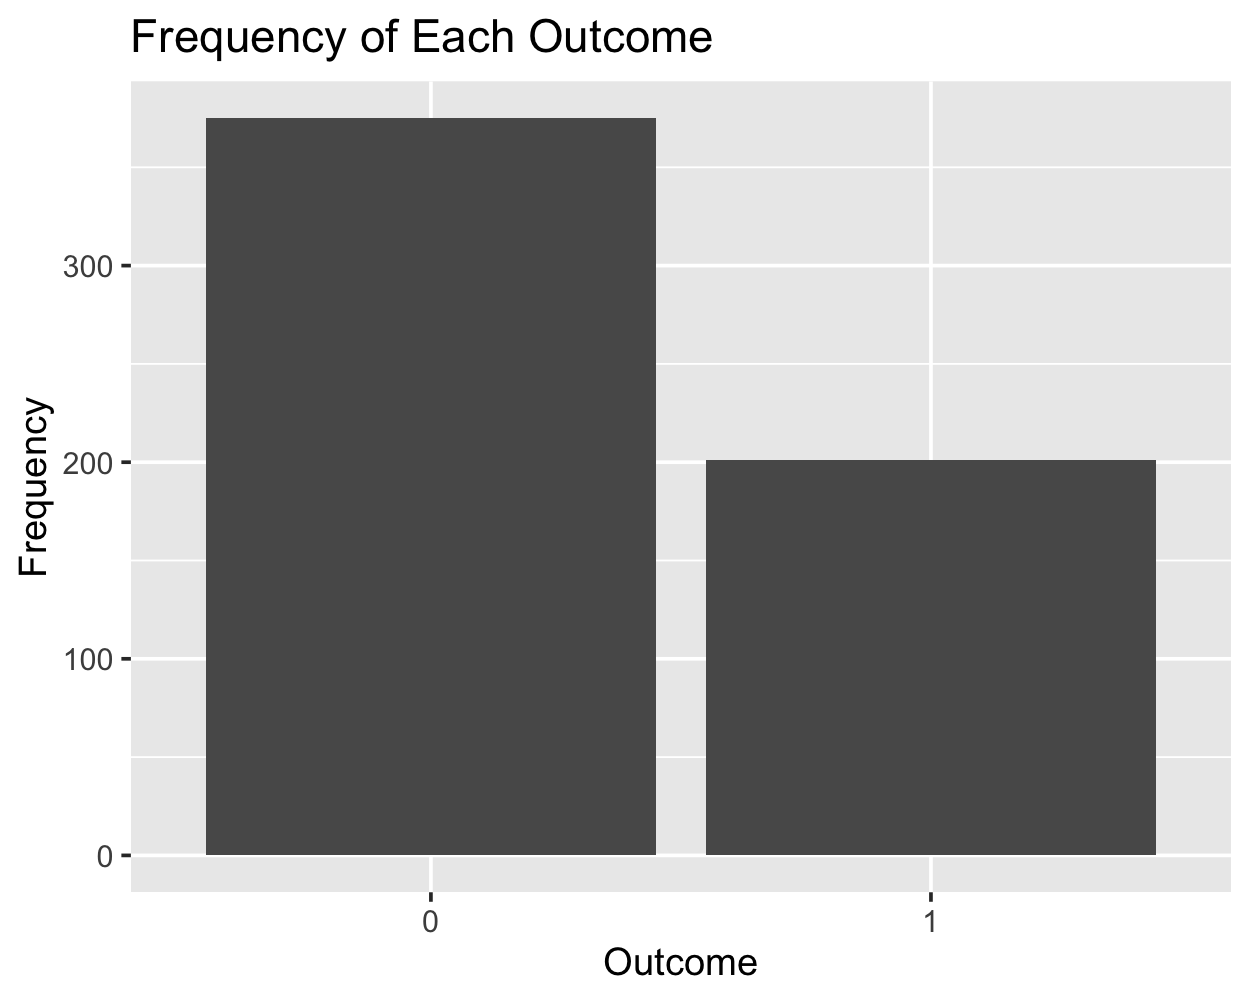

In [13]:
ggplot(diabetes_train, aes(x = Outcome)) +
    geom_bar() +
    labs(x = "Outcome", y = "Frequency", title = "Frequency of Each Outcome")

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

We do not have equal counts of each outcome, so by that definition, the data is imbalanced.


Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [14]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,116.0
0,BMI,25.6
0,Glucose,110.0
0,BMI,37.6
0,Glucose,139.0
0,BMI,27.1


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [ ]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**